In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy, sharpe_ratio, optimize_tt
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest
from src.finance import calculate_beta
from src.portfolio import optimize_portfolio, create_portfolio_df, efficient_frontier

In [2]:
assets = ['AAPL', 'MSFT','SPY', 'NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META', 'QQQ']

returns_df = pd.DataFrame()

for asset in assets:
    df = get_data(asset, "2016-01-01", "2026-01-01")
    df = generate_features(df)
    returns_df[asset] = df["returns"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [3]:
returns_df.head()

,AAPL,MSFT,SPY,NVDA,TTD,DOCS,IBM,BE,XOM,GLD,JNJ,SCCO,ECL,JPM,META,QQQ
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025059,0.004562,0.001691,0.016064,NaN,NaN,-0.000736,NaN,0.008521,0.002819,0.004180,0.011302,0.003645,0.001729,0.004989,-0.001735
2016-01-06,-0.019570,-0.018165,-0.012614,-0.041350,NaN,NaN,-0.005006,NaN,-0.008321,0.014441,-0.005055,-0.028902,-0.042781,-0.014436,0.002336,-0.009606
2016-01-07,-0.042205,-0.034783,-0.023992,-0.039645,NaN,NaN,-0.017090,NaN,-0.016006,0.014140,-0.011655,-0.025397,-0.025909,-0.040439,-0.049043,-0.031313
2016-01-08,0.005288,0.003067,-0.010977,-0.021466,NaN,NaN,-0.009258,NaN,-0.020202,-0.004428,-0.010683,-0.019951,-0.008739,-0.022399,-0.006025,-0.008201


## Correlation Analysis

In [4]:
corr_matrix = returns_df.corr()


In [5]:
corr_matrix.to_csv("../outputs/correlation_matrix.csv")


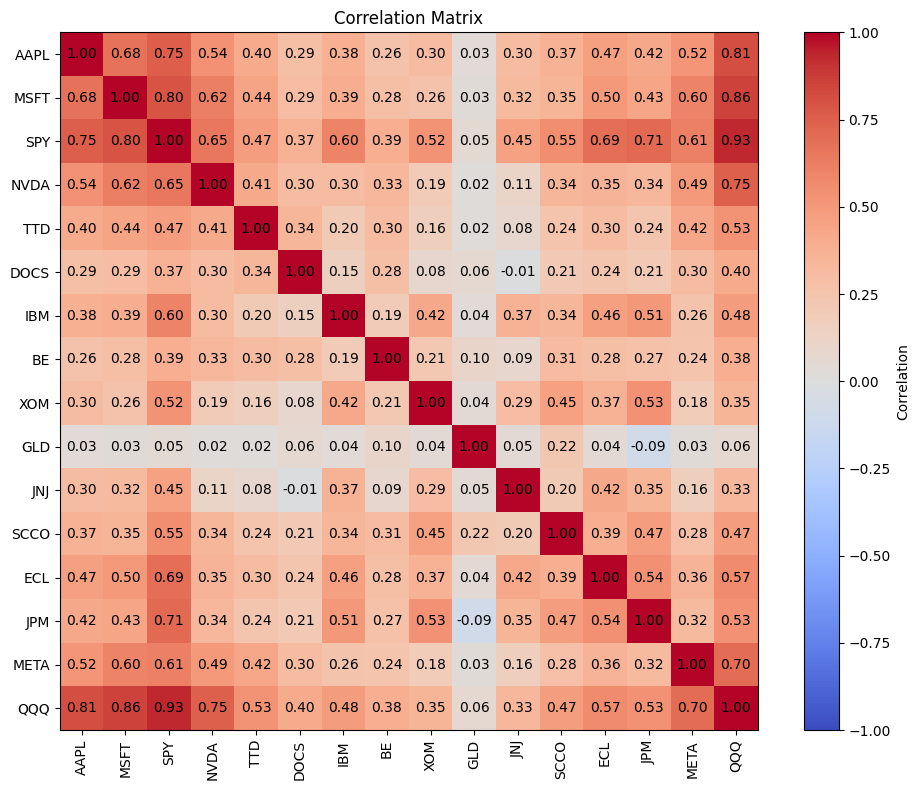

In [6]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

## Covariance Maatrix

In [7]:
cov_matrix = returns_df.cov()
cov_matrix

,AAPL,MSFT,SPY,NVDA,TTD,DOCS,IBM,BE,XOM,GLD,JNJ,SCCO,ECL,JPM,META,QQQ
AAPL,0.000335,0.000209,0.000157,0.000309,0.000320,0.000220,0.000110,0.000304,0.000097,0.000006,0.000064,0.000154,0.000136,0.000133,0.000232,0.000208
MSFT,0.000209,0.000284,0.000153,0.000328,0.000325,0.000209,0.000104,0.000302,0.000078,0.000004,0.000062,0.000133,0.000133,0.000128,0.000246,0.000204
SPY,0.000157,0.000153,0.000130,0.000233,0.000236,0.000180,0.000106,0.000286,0.000105,0.000005,0.000060,0.000143,0.000125,0.000141,0.000169,0.000149
NVDA,0.000309,0.000328,0.000233,0.000988,0.000573,0.000443,0.000149,0.000641,0.000105,0.000006,0.000041,0.000243,0.000175,0.000184,0.000375,0.000331
TTD,0.000320,0.000325,0.000236,0.000573,0.001873,0.000636,0.000138,0.000785,0.000123,0.000009,0.000041,0.000242,0.000209,0.000181,0.000451,0.000327
DOCS,0.000220,0.000209,0.000180,0.000443,0.000636,0.001911,0.000099,0.000649,0.000058,0.000025,-0.000005,0.000214,0.000157,0.000141,0.000370,0.000251
IBM,0.000110,0.000104,0.000106,0.000149,0.000138,0.000099,0.000246,0.000192,0.000116,0.000005,0.000067,0.000122,0.000115,0.000138,0.000097,0.000107
BE,0.000304,0.000302,0.000286,0.000641,0.000785,0.000649,0.000192,0.003505,0.000245,0.000059,0.000062,0.000440,0.000292,0.000297,0.000382,0.000349
XOM,0.000097,0.000078,0.000105,0.000105,0.000123,0.000058,0.000116,0.000245,0.000311,0.000007,0.000059,0.000182,0.000104,0.000164,0.000077,0.000086
GLD,0.000006,0.000004,0.000005,0.000006,0.000009,0.000025,0.000005,0.000059,0.000007,0.000087,0.000005,0.000047,0.000006,-0.000015,0.000006,0.000008


In [8]:
cov_matrix.to_csv("../outputs/covariance_matrix.csv")

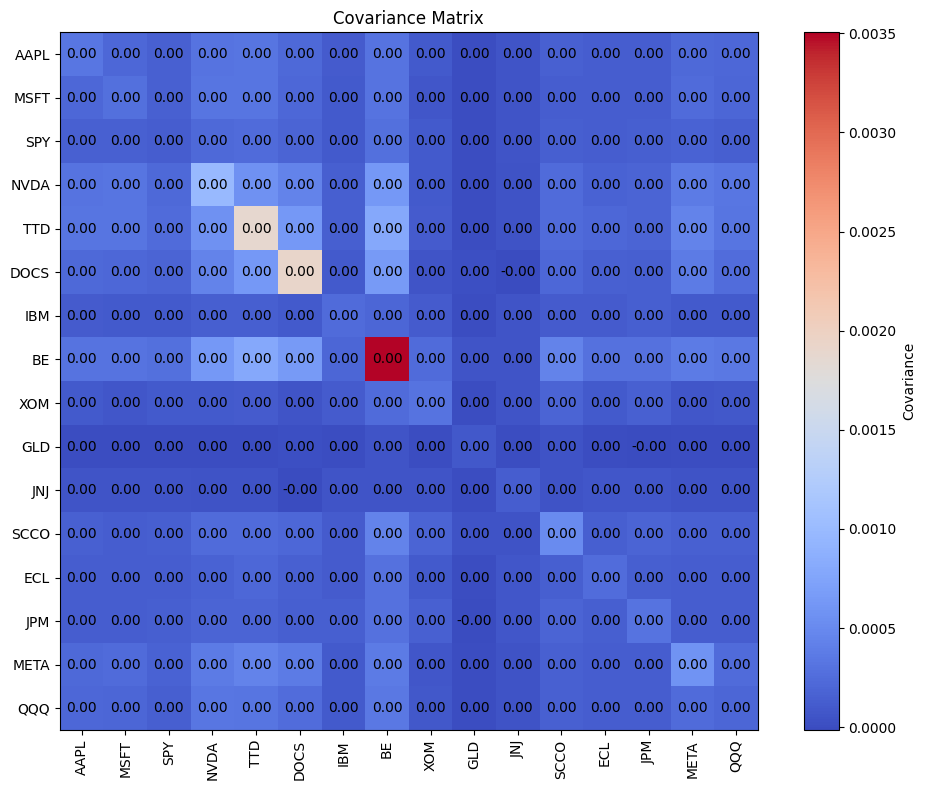

In [9]:
plt.figure(figsize=(10, 8))

plt.imshow(cov_matrix, cmap="coolwarm")

plt.colorbar(label="Covariance")

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns, rotation=90)
plt.yticks(range(len(cov_matrix.index)), cov_matrix.index)

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix.columns)):
        plt.text(j, i, f"{cov_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Covariance Matrix")
plt.tight_layout()

plt.show()

## Portfolio Building

In [10]:
weights_A = {'AAPL': 0.25, 'MSFT': 0.25, 'NVDA': 0.25,'IBM': 0.25}

weights_B = {'AAPL': 0.25,'NVDA': 0.25,'GLD': 0.25,'JNJ': 0.25}

weights_C = {'SPY': 1/3, 'QQQ': 1/3, 'GLD': 1/3}

In [11]:
portfolio_returns_A = (returns_df[list(weights_A.keys())] * list(weights_A.values())).sum(axis=1)
portfolio_return_A = portfolio_returns_A.mean() * 252
portfolio_volatility_A = (portfolio_returns_A.std() * np.sqrt(252))
portfolio_sharpe_A = sharpe_ratio(portfolio_returns_A)
portfolio_cumulative_A = (1 + portfolio_returns_A).cumprod()


portfolio_returns_B = (returns_df[list(weights_B.keys())] * list(weights_B.values())).sum(axis=1)
portfolio_return_B = portfolio_returns_B.mean() * 252
portfolio_volatility_B = (portfolio_returns_B.std() * np.sqrt(252))
portfolio_sharpe_B = sharpe_ratio(portfolio_returns_B)
portfolio_cumulative_B = (1 + portfolio_returns_B).cumprod()

portfolio_returns_C = (returns_df[list(weights_C.keys())] * list(weights_C.values())).sum(axis=1)
portfolio_return_C = portfolio_returns_C.mean() * 252
portfolio_volatility_C = (portfolio_returns_C.std() * np.sqrt(252))
portfolio_sharpe_C = sharpe_ratio(portfolio_returns_C)
portfolio_cumulative_C = (1 + portfolio_returns_C).cumprod()

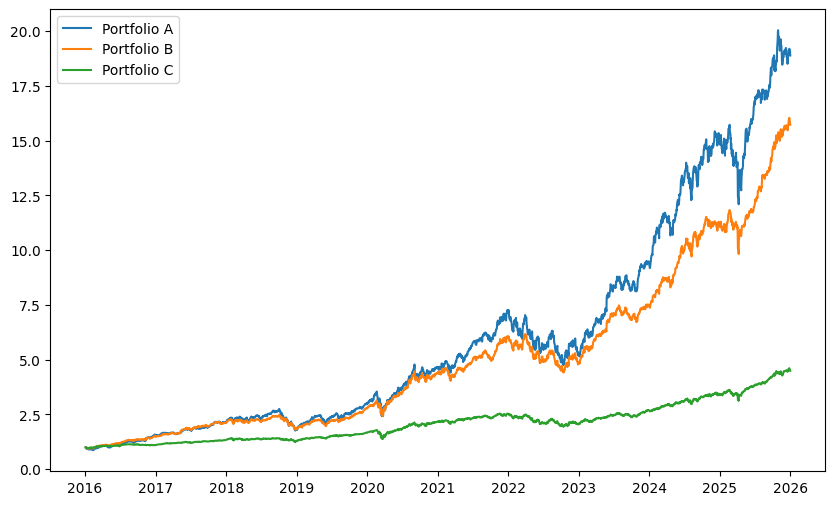

In [12]:
plt.figure(figsize=(10,6))

plt.plot(portfolio_cumulative_A, label="Portfolio A")
plt.plot(portfolio_cumulative_B, label="Portfolio B")
plt.plot(portfolio_cumulative_C, label="Portfolio C")


plt.legend()
plt.show()

In [13]:
summary_table = pd.DataFrame({
    'Annual Return': {
        'Portfolio A': portfolio_return_A,
        'Portfolio B': portfolio_return_B,
        'Portfolio C': portfolio_return_C
    },
    'Annual Volatility': {
        'Portfolio A': portfolio_volatility_A,
        'Portfolio B': portfolio_volatility_B,
        'Portfolio C': portfolio_volatility_C
    },
    'Sharpe Ratio': {
        'Portfolio A': portfolio_sharpe_A,
        'Portfolio B': portfolio_sharpe_B,
        'Portfolio C': portfolio_sharpe_C
    }
})

summary_table

,Annual Return,Annual Volatility,Sharpe Ratio
Portfolio A,0.328311,0.259243,1.266418
Portfolio B,0.295243,0.194642,1.516850
Portfolio C,0.160977,0.143947,1.118311


## Applied Strategies

In [14]:
assets = ['AAPL', 'MSFT', 'NVDA', 'IBM']
strategies = [
    ('Momentum', momentum_strategy, 'mom', None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", range(2, 100, 2), None),
    ("Logistic Regression", logistic_strategy, "lr", None, train_logistic),
    ("Random Forest", randforest_strategy, "rf", None, train_randforest)
]

[*********************100%***********************]  1 of 1 completed

AAPL
Momentum
Market Sharpe Ratio: 0.9056
Best Momentum Strategy window: 14
Best Sharpe ratio: 1.4170

Momentum + Rolling Volatility


Market Sharpe Ratio: 0.9056
Best Momentum + Rolling Volatility Strategy window: 14
Best threshold: 2%
Best Sharpe ratio: 1.6868

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


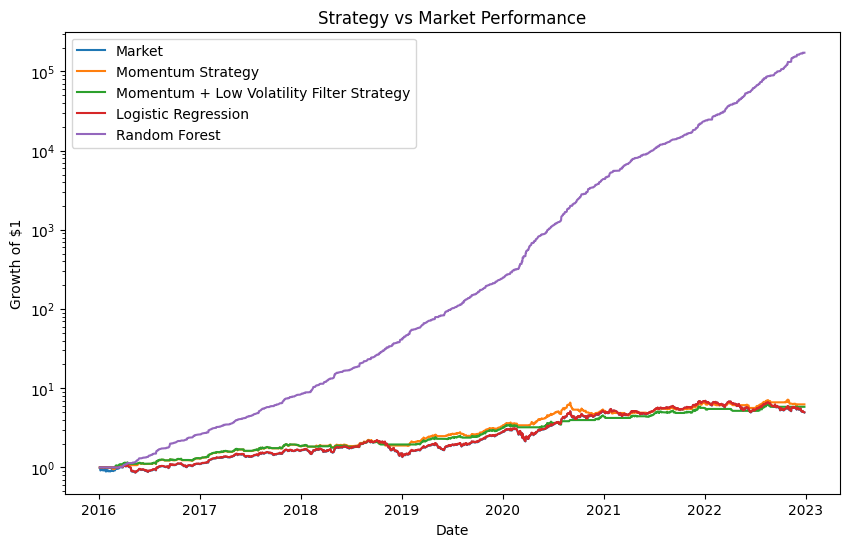

Testing Performance


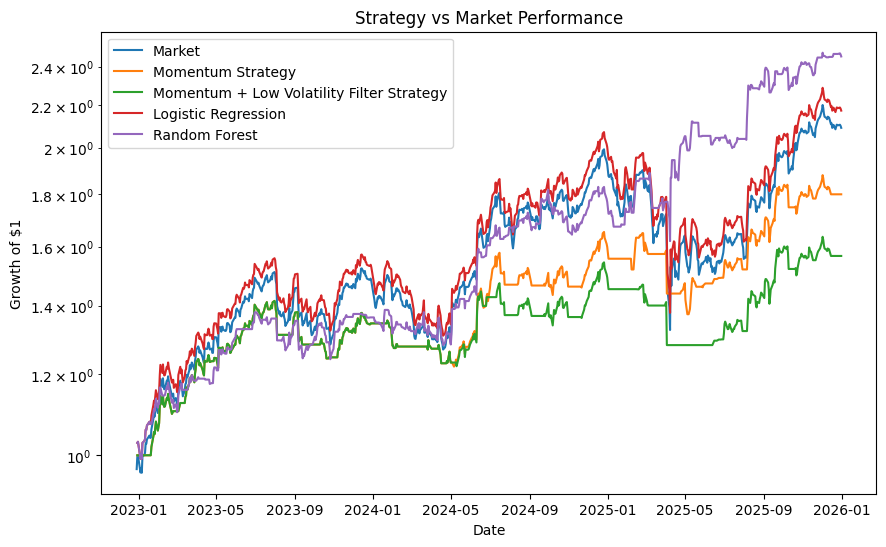

[*********************100%***********************]  1 of 1 completed


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.905573    0.303760 -0.387297   
1                       Momentum  1.416952    0.199519 -0.313157   
2  Momentum + Rolling Volatility  1.686844    0.157121 -0.118903   
3            Logistic Regression  0.918925    0.298881 -0.387297   
4                  Random Forest  9.242371    0.189493  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.525867          0.543907       0.651288        63.445139  
2         0.522456          0.552154       0.522532        50.142126  
3         0.525867          0.528655       0.969957        97.214326  
4         0.984082          1.000000       0.969957        51.392837  

Testing Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.084576    0.257159 -0.3343

Market Sharpe Ratio: 0.8863
Best Momentum + Rolling Volatility Strategy window: 38
Best threshold: 2%
Best Sharpe ratio: 1.0278

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


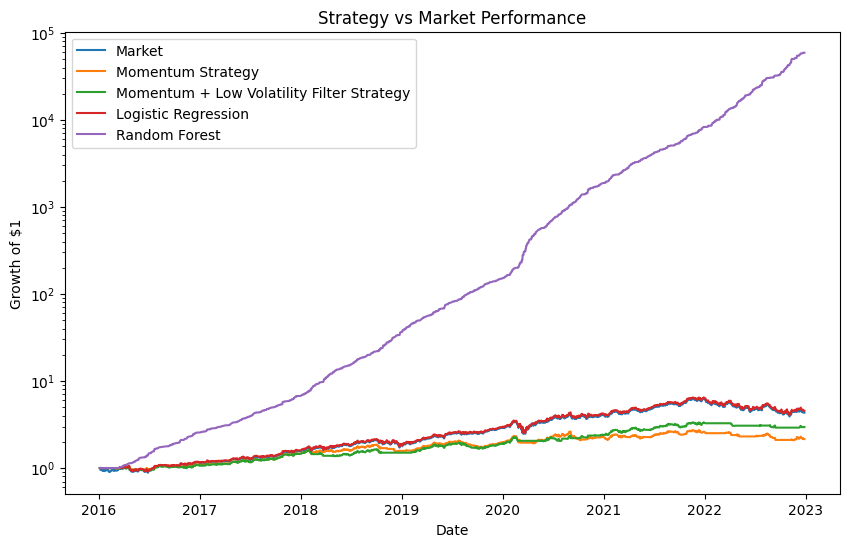

Testing Performance


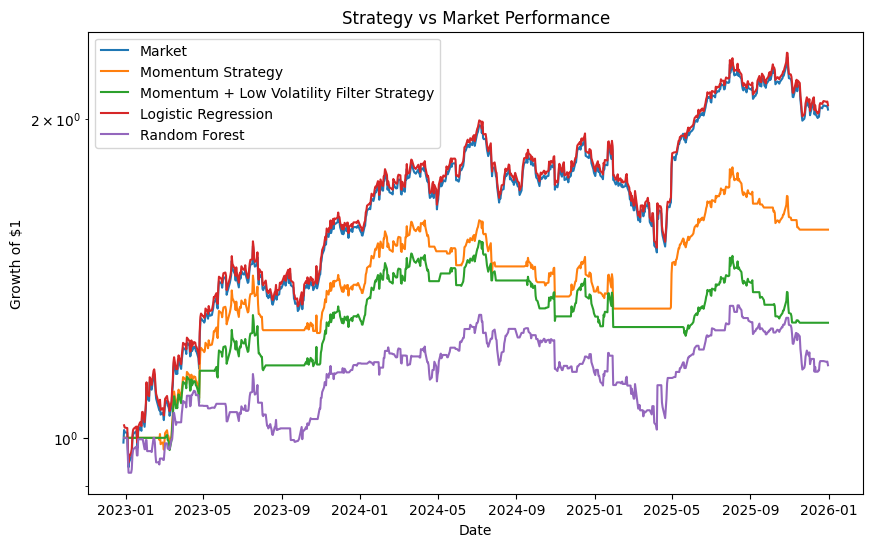

[*********************100%***********************]  1 of 1 completed


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.886335    0.281585 -0.375565   
1                       Momentum  0.674419    0.189500 -0.235351   
2  Momentum + Rolling Volatility  1.027824    0.164306 -0.154479   
3            Logistic Regression  0.927021    0.275509 -0.375565   
4                  Random Forest  9.083516    0.175537  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.523024          0.540284       0.726886        71.972712  
2         0.524161          0.547101       0.641870        62.762933  
3         0.537237          0.537331       0.971307        96.702672  
4         0.986924          1.000000       0.975558        52.188744  

Testing Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.141846    0.231916 -0.2416

Market Sharpe Ratio: 1.0716
Best Momentum + Rolling Volatility Strategy window: 20
Best threshold: 4%
Best Sharpe ratio: 1.3043

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


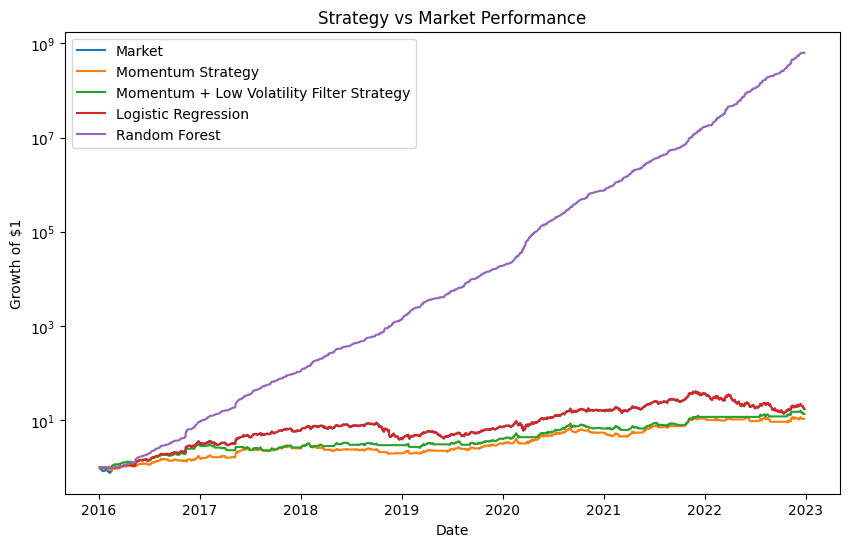

Testing Performance


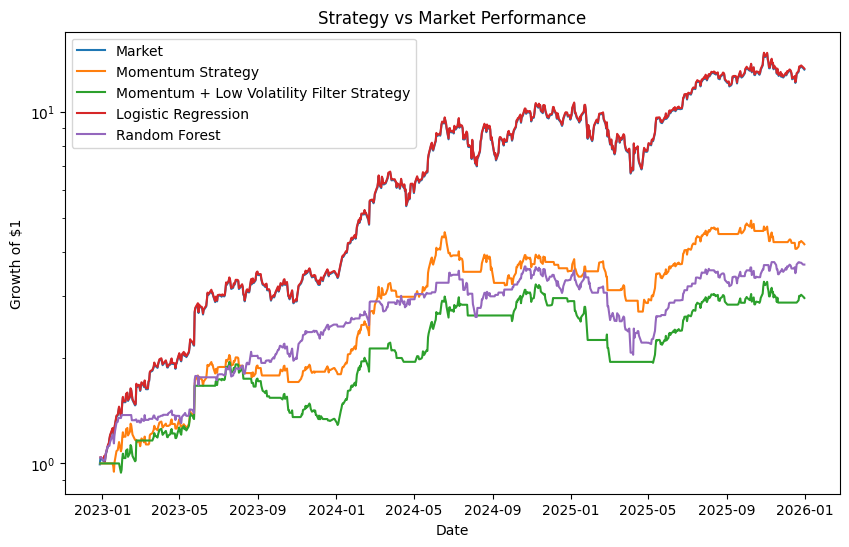

[*********************100%***********************]  1 of 1 completed


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.071563    0.497546 -0.663621   
1                       Momentum  1.177565    0.338559 -0.397698   
2  Momentum + Rolling Volatility  1.304293    0.328520 -0.304279   
3            Logistic Regression  1.079549    0.492507 -0.663621   
4                  Random Forest  9.325382    0.318387  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.513928          0.544304       0.631689        62.876634  
2         0.513928          0.548134       0.585519        57.873792  
3         0.540080          0.542105       0.972718        97.214326  
4         0.985219          1.000000       0.972718        52.700398  

Testing Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.966785    0.501239 -0.3688

Market Sharpe Ratio: 0.1790
Best Momentum + Rolling Volatility Strategy window: 12
Best threshold: 8%
Best Sharpe ratio: 0.4267

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


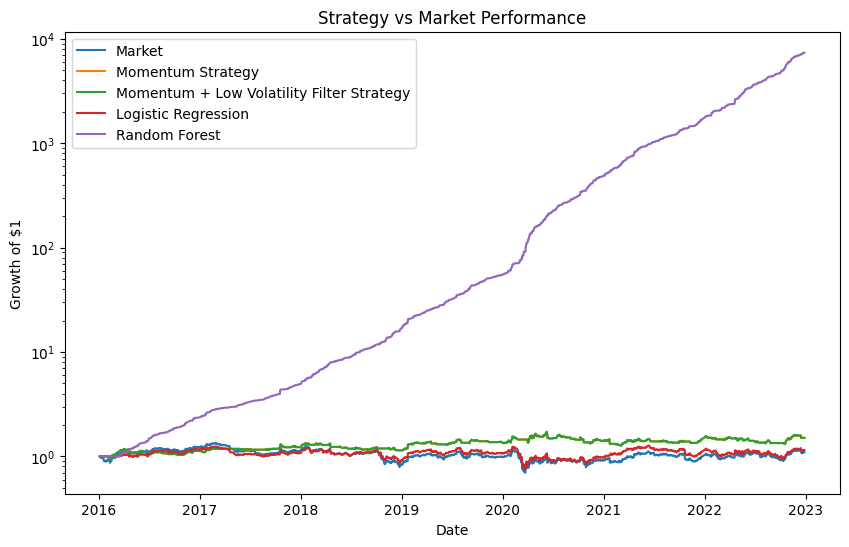

Testing Performance


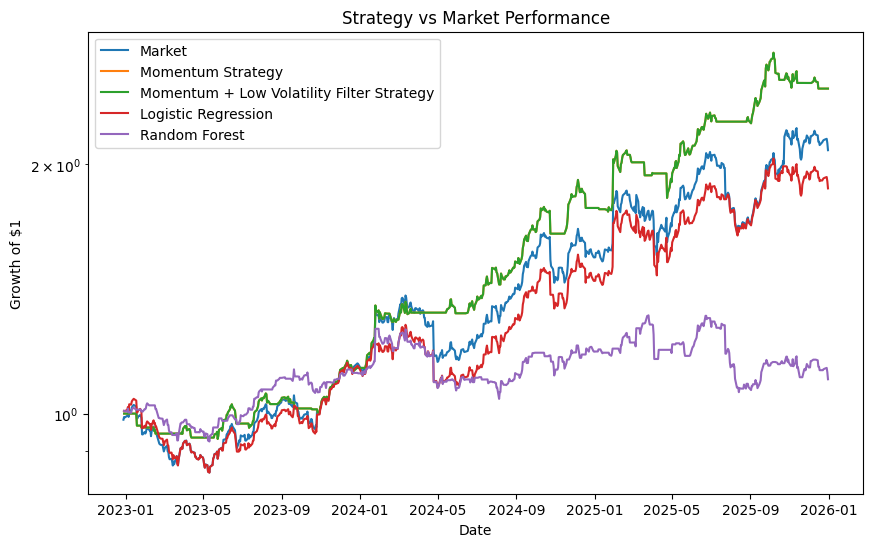


Training Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  0.179044    0.252983 -0.479143   
1                       Momentum  0.426745    0.171460 -0.267153   
2  Momentum + Rolling Volatility  0.426745    0.171460 -0.267153   
3            Logistic Regression  0.204445    0.240946 -0.398900   
4                  Random Forest  8.600737    0.150005  0.000000   

   Signal Accuracy  Signal Precision  Signal Recall  Signal Active %  
0              NaN               NaN            NaN              NaN  
1         0.509949          0.528796       0.550709        54.292211  
2         0.509949          0.528796       0.550709        54.292211  
3         0.517908          0.520746       0.944384        94.542354  
4         0.985219          1.000000       0.971647        50.653781  

Testing Results
                        Strategy    Sharpe  Volatility    Max DD  \
0                         Market  1.139804    0.239352 -0.2035

In [15]:
optimize_assets(
    assets,
    "2016-01-01",
    "2026-01-01",
    strategies,
    feature_set='v1',
    windows=range(2, 50, 2),
    logscale=True,
    save_csv=False
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Momentum
Market Sharpe Ratio: 0.9428
Best Momentum Strategy window: 12
Best Sharpe ratio: 1.1210

Momentum + Rolling Volatility


Market Sharpe Ratio: 0.9428
Best Momentum + Rolling Volatility Strategy window: 10
Best threshold: 2%
Best Sharpe ratio: 1.4070

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.

Training Performance


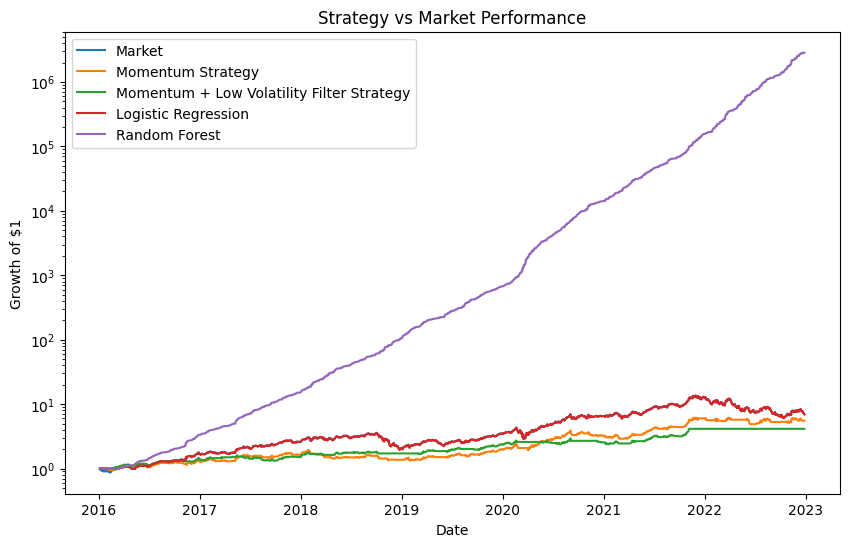

Testing Performance


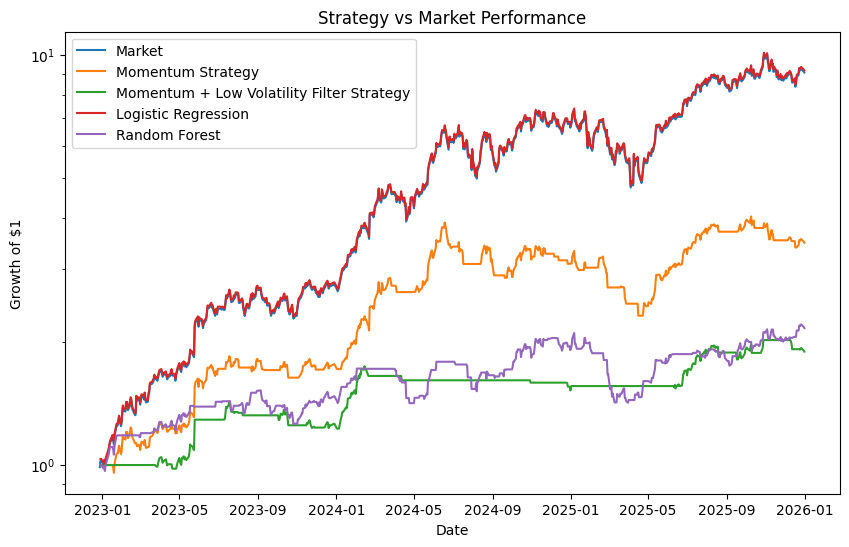

In [16]:
portfolio_A = create_portfolio_df(
    weights_A,
    "2016-01-01",
    "2026-01-01"
)

portfolio_A = generate_features(portfolio_A)

split_idx = int(len(portfolio_A) * 0.7)

train_A = portfolio_A.iloc[:split_idx].copy()
test_A = portfolio_A.iloc[split_idx:].copy()

train_results_A, test_results_A = optimize_tt(
    train=train_A,
    test=test_A,
    strategies=strategies,
    windows=range(2, 50, 2),
    feature_set="v1",
    asset="Portfolio B",
    save_csv=False,
    windowplot=False,
    performanceplot=True,
    logscale=True
)

In [17]:
results_table(train_A)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.942777,0.366140,-0.554597,NaN,NaN,NaN,NaN
1,Momentum,1.120952,0.246098,-0.307626,0.519613,0.552305,0.646937,64.127345
2,Momentum + Rolling Volatility,1.406966,0.152957,-0.185768,0.508812,0.568088,0.428868,41.330301
3,Logistic Regression,0.945540,0.363467,-0.554597,0.546902,0.548538,0.974039,97.214326
4,Random Forest,9.605254,0.225205,0.000000,0.985787,1.000000,0.974039,53.325753


In [18]:
results_table(test_A)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,1.887988,0.440806,-0.351228,NaN,NaN,NaN,NaN
1,Momentum,1.455025,0.321772,-0.407365,0.504636,0.545082,0.636364,64.635762
2,Momentum + Rolling Volatility,1.257103,0.181859,-0.143166,0.460927,0.528497,0.244019,25.562914
3,Logistic Regression,1.898291,0.441016,-0.351228,0.553642,0.553642,1.000000,100.000000
4,Random Forest,1.103660,0.264563,-0.323996,0.496689,0.551913,0.483254,48.476821


## Efficient Frontier

In [19]:
assets_A = ['AAPL', 'MSFT', 'NVDA', 'IBM']
assets_B = ['AAPL', 'NVDA', 'GLD', 'JNJ']
assets_C = ['SPY', 'QQQ', 'GLD']

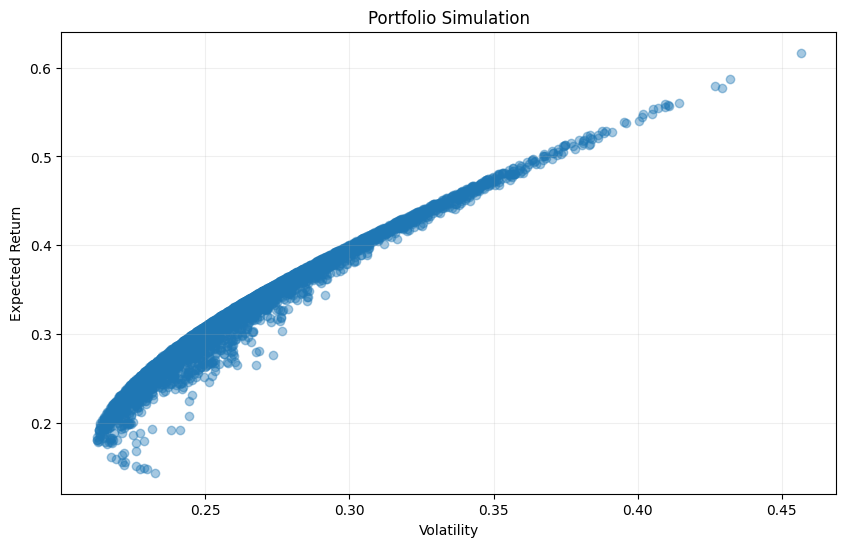

(array([0.32174772, 0.31944101, 0.29827567, ..., 0.32946058, 0.29364076,
        0.2185684 ], shape=(5000,)),
 array([0.25591489, 0.26673605, 0.24488122, ..., 0.26027402, 0.24741833,
        0.21747725], shape=(5000,)))

In [31]:
efficient_frontier(assets = assets_A, returns_df = returns_df)

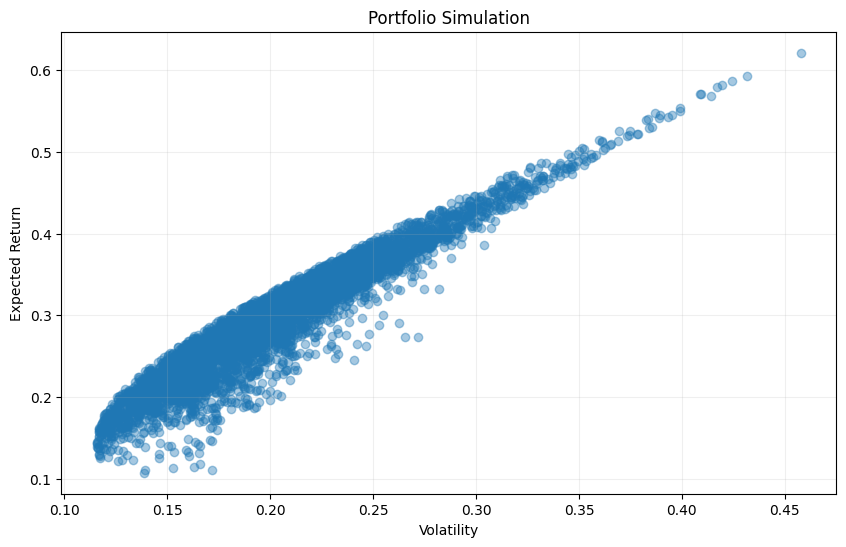

(array([0.35307152, 0.32180718, 0.33912042, ..., 0.25336604, 0.15233303,
        0.40831762], shape=(5000,)),
 array([0.2369401 , 0.24595593, 0.24180997, ..., 0.15139464, 0.12263043,
        0.27251817], shape=(5000,)))

In [29]:
efficient_frontier(assets = assets_B, returns_df = returns_df)

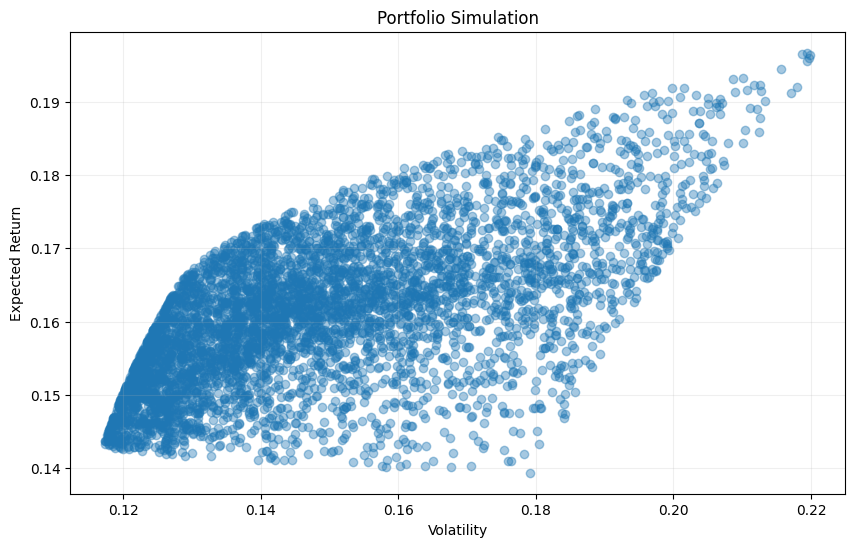

(array([0.17237036, 0.17719669, 0.1622245 , ..., 0.16571685, 0.16785772,
        0.16698775], shape=(5000,)),
 array([0.19058521, 0.17994738, 0.13132221, ..., 0.13767337, 0.17979574,
        0.18132087], shape=(5000,)))

In [26]:
efficient_frontier(assets = assets_C, returns_df = returns_df)